# Fashion MNIST 분류 프로젝트 리포트

## 프로젝트 개요
이번 실습은 28×28 흑백 의류 이미지 데이터를 바탕으로  
어떤 모델이 이미지의 형태 정보를 더 안정적으로 구분하는지 확인하는 데 목적이 있다.  
단순히 정확도를 비교하는 데서 끝내지 않고,  
오분류 양상과 실제 사진 적용 가능성까지 함께 살펴보았다.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
from PIL import Image, ImageOps, ImageEnhance

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten,
    Conv2D, MaxPooling2D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 한글 폰트 설정
mpl.rcParams['axes.unicode_minus'] = False
available_fonts = [f.name for f in fm.fontManager.ttflist]
for font_name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Batang', 'Gulim']:
    if font_name in available_fonts:
        mpl.rcParams['font.family'] = font_name
        break

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

I0000 00:00:1775032015.896888  234901 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775032015.965215  234901 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775032017.056684  234901 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. 데이터 불러오기와 기본 확인

Fashion MNIST는 해상도가 매우 낮은 편이지만,  
그 안에서도 의류의 윤곽과 위치 정보가 분류 성능에 직접적인 영향을 준다.  
따라서 학습을 시작하기 전에 데이터의 형태와 클래스 구성을 먼저 점검하고,  
이 데이터에서 어떤 정보가 핵심이 될지 확인할 필요가 있다.

In [2]:
# 원본 로드
(X_train_raw, y_train), (X_test_raw, y_test) = fashion_mnist.load_data()

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape :", X_test_raw.shape)

# 모델 입력용 전처리
X_train = X_train_raw.astype("float32") / 255.0
X_test  = X_test_raw.astype("float32") / 255.0

X_train_cnn = X_train[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

display(pd.Series(y_train).value_counts().sort_index().rename(index=dict(enumerate(class_names))).to_frame("train_count"))

X_train_raw shape: (60000, 28, 28)
X_test_raw shape : (10000, 28, 28)


,train_count
T-shirt/top,6000
Trouser,6000
Pullover,6000
Dress,6000
Coat,6000
Sandal,6000
Shirt,6000
Sneaker,6000
Bag,6000
Ankle boot,6000


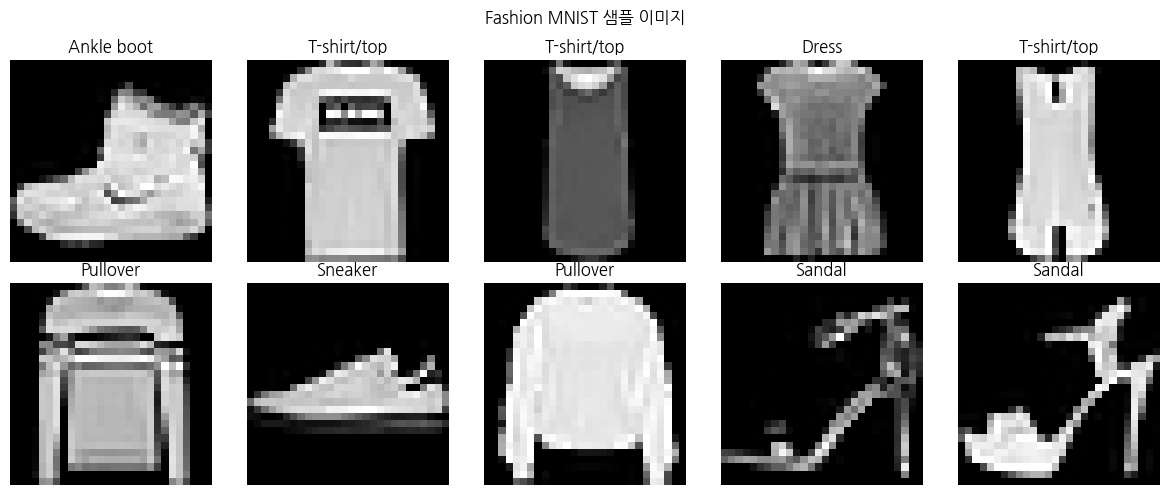

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample_idx = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(X_train_raw[idx], cmap="gray")
    ax.set_title(f"{class_names[y_train[idx]]}")
    ax.axis("off")

plt.suptitle("Fashion MNIST 샘플 이미지")
plt.tight_layout()
plt.show()

### 데이터 관찰
샘플 이미지를 보면 배경은 단순하지만 클래스 간 형태 차이는 아주 크지 않다.  
특히 상의 계열 클래스는 외형이 비슷해 보이는 경우가 많아,  
작은 해상도 안에서 미세한 차이를 구분해야 한다는 점을 확인할 수 있다.

이 단계의 관찰은 이후 모델 선택의 근거가 된다.  
픽셀 값을 단순히 일렬로 해석하는 방식보다,  
주변 픽셀의 배치와 형태를 함께 읽는 구조가 더 적합할 가능성이 높다.

## 2. 비교 기준으로서의 DNN 베이스라인

먼저 DNN을 사용해 기준 성능을 확인한다.  
이 단계의 목적은 최종 성능을 만드는 것이 아니라,  
공간 정보를 충분히 활용하지 않는 모델이 이 문제를 어느 정도까지 풀 수 있는지 살펴보는 것이다.

이 기준점이 있어야 이후 CNN의 성능 차이를 단순한 수치 비교가 아니라  
입력 구조를 다루는 방식의 차이로 해석할 수 있다.

In [4]:
def build_dnn():
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

dnn_model = build_dnn()
dnn_history = dnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.2,
    epochs=8,
    batch_size=128,
    verbose=2
)

dnn_test_loss, dnn_test_acc = dnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"DNN 테스트 정확도: {dnn_test_acc:.4f}")

I0000 00:00:1775032018.640564  234901 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2051 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/8


I0000 00:00:1775032021.559277  235036 service.cc:153] XLA service 0x784330033d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775032021.559302  235036 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775032021.575435  235036 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775032021.672313  235036 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775032021.708906  235036 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1467__.19
I0000 00:00:1775032021.745867  235036 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

375/375 - 6s - 16ms/step - accuracy: 0.7781 - loss: 0.6203 - val_accuracy: 0.8432 - val_loss: 0.4241
Epoch 2/8
375/375 - 1s - 3ms/step - accuracy: 0.8415 - loss: 0.4356 - val_accuracy: 0.8577 - val_loss: 0.3929
Epoch 3/8
375/375 - 1s - 3ms/step - accuracy: 0.8569 - loss: 0.3951 - val_accuracy: 0.8621 - val_loss: 0.3701
Epoch 4/8
375/375 - 1s - 3ms/step - accuracy: 0.8656 - loss: 0.3678 - val_accuracy: 0.8727 - val_loss: 0.3489
Epoch 5/8
375/375 - 1s - 3ms/step - accuracy: 0.8696 - loss: 0.3533 - val_accuracy: 0.8725 - val_loss: 0.3467
Epoch 6/8
375/375 - 1s - 3ms/step - accuracy: 0.8764 - loss: 0.3388 - val_accuracy: 0.8782 - val_loss: 0.3343
Epoch 7/8
375/375 - 1s - 3ms/step - accuracy: 0.8797 - loss: 0.3282 - val_accuracy: 0.8786 - val_loss: 0.3327
Epoch 8/8
375/375 - 1s - 3ms/step - accuracy: 0.8816 - loss: 0.3193 - val_accuracy: 0.8749 - val_loss: 0.3305
DNN 테스트 정확도: 0.8700


## 3. 기본 CNN

다음으로 CNN을 적용한다.  
CNN은 인접한 픽셀 간의 관계를 보존한 채 특징을 추출하므로,  
의류의 윤곽선이나 부분 형태를 반영하기에 더 적합하다.

즉, 여기서 기대하는 개선은 모델 규모 자체보다는  
데이터 구조와 모델 구조가 더 잘 맞아떨어지는 데서 나온다고 볼 수 있다.

In [5]:
def build_basic_cnn():
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.4),
        Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

basic_cnn = build_basic_cnn()
basic_cnn_history = basic_cnn.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.2,
    epochs=8,
    batch_size=128,
    verbose=2
)

basic_cnn_test_loss, basic_cnn_test_acc = basic_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"기본 CNN 테스트 정확도: {basic_cnn_test_acc:.4f}")

Epoch 1/8


I0000 00:00:1775032039.850679  235037 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20006__.35


375/375 - 6s - 15ms/step - accuracy: 0.7492 - loss: 0.6931 - val_accuracy: 0.8508 - val_loss: 0.4212
Epoch 2/8
375/375 - 2s - 4ms/step - accuracy: 0.8430 - loss: 0.4371 - val_accuracy: 0.8715 - val_loss: 0.3577
Epoch 3/8
375/375 - 1s - 4ms/step - accuracy: 0.8640 - loss: 0.3795 - val_accuracy: 0.8837 - val_loss: 0.3293
Epoch 4/8
375/375 - 1s - 4ms/step - accuracy: 0.8747 - loss: 0.3434 - val_accuracy: 0.8883 - val_loss: 0.3107
Epoch 5/8
375/375 - 1s - 4ms/step - accuracy: 0.8843 - loss: 0.3177 - val_accuracy: 0.8942 - val_loss: 0.2905
Epoch 6/8
375/375 - 2s - 4ms/step - accuracy: 0.8907 - loss: 0.2977 - val_accuracy: 0.8953 - val_loss: 0.2809
Epoch 7/8
375/375 - 1s - 4ms/step - accuracy: 0.8979 - loss: 0.2815 - val_accuracy: 0.9007 - val_loss: 0.2728
Epoch 8/8
375/375 - 1s - 4ms/step - accuracy: 0.9023 - loss: 0.2663 - val_accuracy: 0.9022 - val_loss: 0.2619
기본 CNN 테스트 정확도: 0.9010


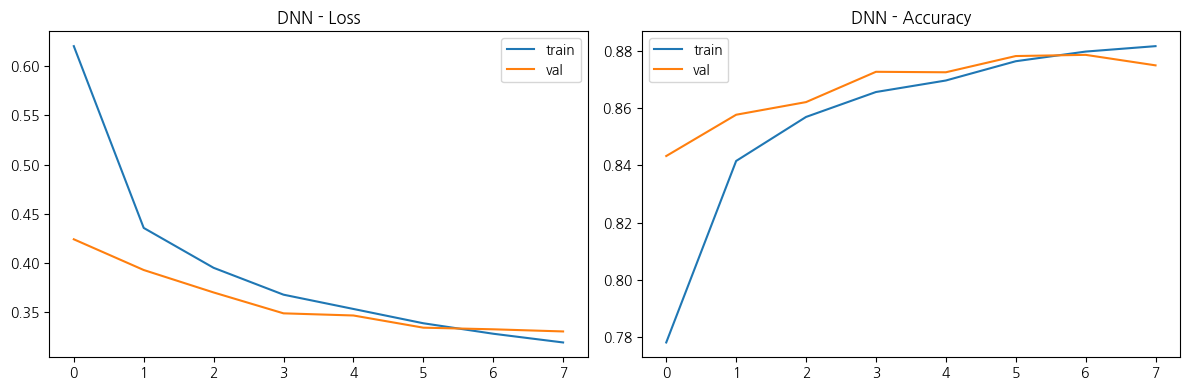

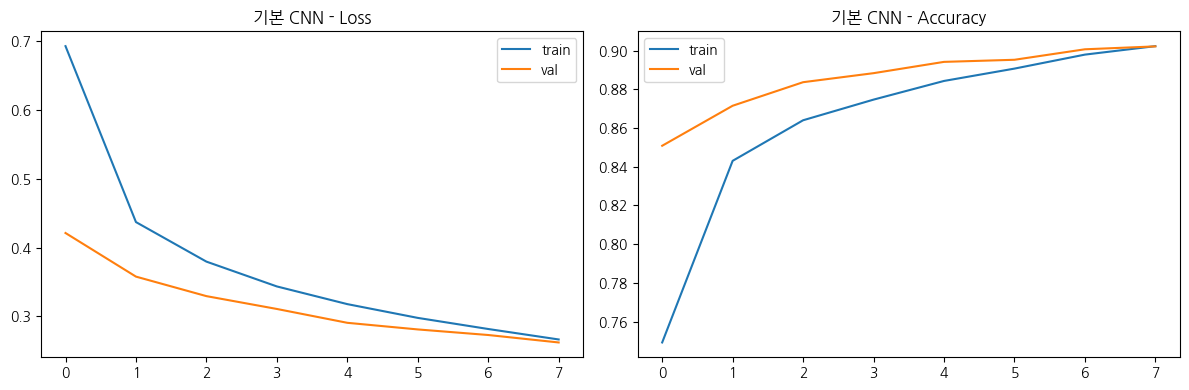

In [6]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title} - Loss")
    axes[0].legend()

    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="val")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(dnn_history, "DNN")
plot_history(basic_cnn_history, "기본 CNN")

In [7]:
comparison_df = pd.DataFrame({
    "모델": ["DNN", "기본 CNN"],
    "Test Accuracy": [dnn_test_acc, basic_cnn_test_acc]
}).sort_values("Test Accuracy", ascending=False)

display(comparison_df)

,모델,Test Accuracy
1,기본 CNN,0.901
0,DNN,0.870


In [8]:
# 결과 해설
best_model_name = comparison_df.iloc[0]["모델"]
best_model_acc = comparison_df.iloc[0]["Test Accuracy"]
worst_model_name = comparison_df.iloc[-1]["모델"]
worst_model_acc = comparison_df.iloc[-1]["Test Accuracy"]
gap = best_model_acc - worst_model_acc

print(f"비교 결과, {best_model_name}의 테스트 정확도가 가장 높게 나타났다.")
print(f"정확도 차이는 {gap:.4f}p로, {worst_model_name} 대비 형태 정보를 더 잘 활용했음을 시사한다.")
print("이 결과는 Fashion MNIST에서 픽셀의 위치 관계를 보존하는 방식이 유리하다는 해석과 연결된다.")

비교 결과, 기본 CNN의 테스트 정확도가 가장 높게 나타났다.
정확도 차이는 0.0310p로, DNN 대비 형태 정보를 더 잘 활용했음을 시사한다.
이 결과는 Fashion MNIST에서 픽셀의 위치 관계를 보존하는 방식이 유리하다는 해석과 연결된다.


### 결과 해석
이 단계에서는 대체로 CNN이 DNN보다 높은 정확도를 보인다.  
이는 Fashion MNIST에서 중요한 정보가 단순한 밝기 분포가 아니라  
형태와 위치 관계라는 점을 다시 보여준다.

정확도 차이가 아주 크지 않더라도 의미는 분명하다.  
같은 데이터를 사용하더라도 입력 구조를 보존하는 방식이  
의류 이미지 분류에 더 자연스럽게 작동한다는 해석이 가능하다.

## 4. 개선 CNN: 학습 안정화

기본 CNN 이후에는 구조를 과도하게 복잡하게 늘리기보다는  
학습 과정이 불안정해지지 않도록 다듬는 방향을 선택했다.

여기서 반영한 요소는 다음과 같다.

- **Batch Normalization**: 층별 출력 분포를 안정화해 학습 흐름 개선
- **Dropout**: 과적합 완화
- **EarlyStopping / ReduceLROnPlateau**: 불필요한 과학습 방지
- **Image Augmentation**: 제한적인 범위 안에서 일반화 성능 보완

다만 Fashion MNIST는 원본 이미지가 단순하고 방향성도 비교적 뚜렷하므로,  
증강을 강하게 적용하면 오히려 데이터 특성을 흐릴 수 있다.  
그래서 이번 실험에서는 과장된 변형보다 보수적인 수준의 증강만 사용하였다.

In [9]:
aug = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.05
)

def build_improved_cnn():
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(32, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.4),
        Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6)
]

improved_cnn = build_improved_cnn()
improved_history = improved_cnn.fit(
    aug.flow(X_train_cnn, y_train_cat, batch_size=128),
    validation_data=(X_test_cnn, y_test_cat),
    steps_per_epoch=len(X_train_cnn) // 128,
    epochs=12,
    callbacks=callbacks,
    verbose=2
)

improved_test_loss, improved_test_acc = improved_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"개선 CNN 테스트 정확도: {improved_test_acc:.4f}")

Epoch 1/12


I0000 00:00:1775032056.889119  234901 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1775032058.308688  235038 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39475__.47
I0000 00:00:1775032065.512609  235038 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39475__.47


468/468 - 15s - 33ms/step - accuracy: 0.7648 - loss: 0.6468 - val_accuracy: 0.7913 - val_loss: 0.5314 - learning_rate: 0.0010
Epoch 2/12


/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


468/468 - 1s - 1ms/step - accuracy: 0.7969 - loss: 0.5723 - val_accuracy: 0.7975 - val_loss: 0.5182 - learning_rate: 0.0010
Epoch 3/12
468/468 - 5s - 11ms/step - accuracy: 0.8289 - loss: 0.4603 - val_accuracy: 0.8710 - val_loss: 0.3566 - learning_rate: 0.0010
Epoch 4/12
468/468 - 1s - 2ms/step - accuracy: 0.8594 - loss: 0.4641 - val_accuracy: 0.8654 - val_loss: 0.3666 - learning_rate: 0.0010
Epoch 5/12
468/468 - 8s - 16ms/step - accuracy: 0.8462 - loss: 0.4168 - val_accuracy: 0.8523 - val_loss: 0.3932 - learning_rate: 0.0010
Epoch 6/12
468/468 - 1s - 2ms/step - accuracy: 0.8516 - loss: 0.3839 - val_accuracy: 0.8614 - val_loss: 0.3787 - learning_rate: 5.0000e-04
개선 CNN 테스트 정확도: 0.8710


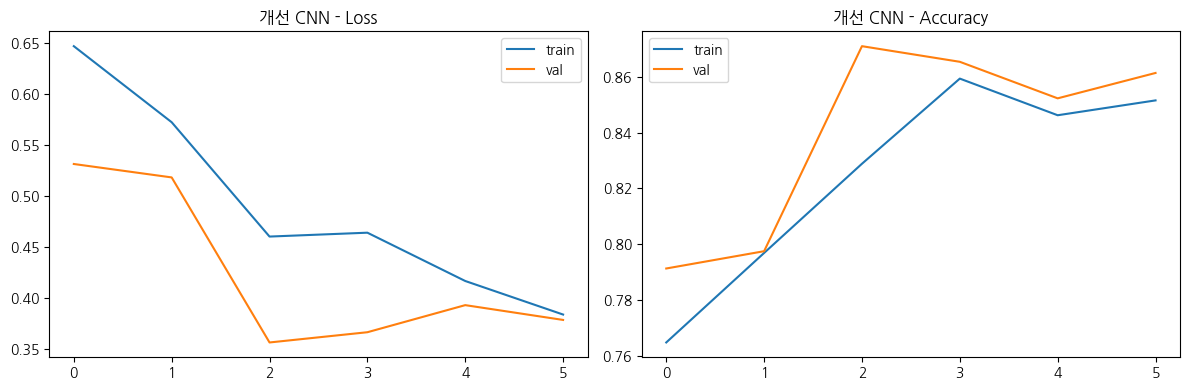

,모델,Test Accuracy
1,기본 CNN,0.901
2,개선 CNN,0.871
0,DNN,0.870


In [10]:
plot_history(improved_history, "개선 CNN")

final_comparison_df = pd.DataFrame({
    "모델": ["DNN", "기본 CNN", "개선 CNN"],
    "Test Accuracy": [dnn_test_acc, basic_cnn_test_acc, improved_test_acc]
}).sort_values("Test Accuracy", ascending=False)

display(final_comparison_df)

In [11]:
# 개선 CNN 결과 해설
ranked = final_comparison_df.reset_index(drop=True)
top_model = ranked.loc[0, "모델"]
top_acc = ranked.loc[0, "Test Accuracy"]
base_acc = ranked.loc[ranked["모델"]=="기본 CNN", "Test Accuracy"].iloc[0]
improved_gain = improved_test_acc - base_acc

print(f"최종 비교에서는 {top_model}이 가장 높은 정확도를 기록했다.")
print(f"개선 CNN은 기본 CNN 대비 {improved_gain:.4f}p 만큼 변화하였다.")
if improved_gain > 0:
    print("증가 폭이 크지 않더라도, 이는 구조 자체보다는 학습 안정화 장치가 성능을 보완한 결과로 볼 수 있다.")
elif improved_gain < 0:
    print("정확도가 소폭 낮아졌다면, 보수적 증강과 정규화가 일반화에는 기여했더라도 단일 지표상 이득은 제한적이었음을 의미한다.")
else:
    print("정확도 차이가 거의 없다면, 추가 기법은 성능 향상보다 학습 안정성 확보에 더 의미가 있었다고 해석할 수 있다.")

최종 비교에서는 기본 CNN이 가장 높은 정확도를 기록했다.
개선 CNN은 기본 CNN 대비 -0.0300p 만큼 변화하였다.
정확도가 소폭 낮아졌다면, 보수적 증강과 정규화가 일반화에는 기여했더라도 단일 지표상 이득은 제한적이었음을 의미한다.


## 5. 오분류 분석

정확도는 전체 성능을 빠르게 파악하는 데 유용하지만,  
모델이 실제로 어떤 지점에서 흔들리는지는 오분류를 봐야 더 분명해진다.

Fashion MNIST는 클래스 이름보다 실제 형태가 더 중요하게 작용하는 데이터이므로,  
혼동 행렬과 오분류 사례를 함께 보면 모델의 한계와 데이터의 난점이 동시에 드러난다.

In [12]:
final_model = improved_cnn

probs = final_model.predict(X_test_cnn, verbose=0)
preds = probs.argmax(axis=1)

print(classification_report(y_test, preds, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.83      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.87      0.75      0.81      1000
       Dress       0.87      0.88      0.87      1000
        Coat       0.80      0.75      0.78      1000
      Sandal       0.94      0.99      0.96      1000
       Shirt       0.58      0.68      0.63      1000
     Sneaker       0.94      0.94      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.99      0.94      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



In [13]:
# 분류 성능 해설
report_dict = classification_report(y_test, preds, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).T
support_classes = report_df.loc[class_names].copy()
best_recall_class = support_classes["recall"].idxmax()
worst_recall_class = support_classes["recall"].idxmin()
best_precision_class = support_classes["precision"].idxmax()
worst_precision_class = support_classes["precision"].idxmin()

print(f"재현율이 가장 높은 클래스는 {best_recall_class}이고, 가장 낮은 클래스는 {worst_recall_class}이다.")
print(f"정밀도가 가장 높은 클래스는 {best_precision_class}이고, 가장 낮은 클래스는 {worst_precision_class}이다.")
print("일반적으로 가방이나 발목 부츠처럼 형태가 비교적 뚜렷한 클래스는 잘 구분되고,")
print("셔츠류처럼 외형이 비슷한 클래스는 상대적으로 혼동이 많이 발생하는 경향이 있다.")

재현율이 가장 높은 클래스는 Sandal이고, 가장 낮은 클래스는 Shirt이다.
정밀도가 가장 높은 클래스는 Trouser이고, 가장 낮은 클래스는 Shirt이다.
일반적으로 가방이나 발목 부츠처럼 형태가 비교적 뚜렷한 클래스는 잘 구분되고,
셔츠류처럼 외형이 비슷한 클래스는 상대적으로 혼동이 많이 발생하는 경향이 있다.


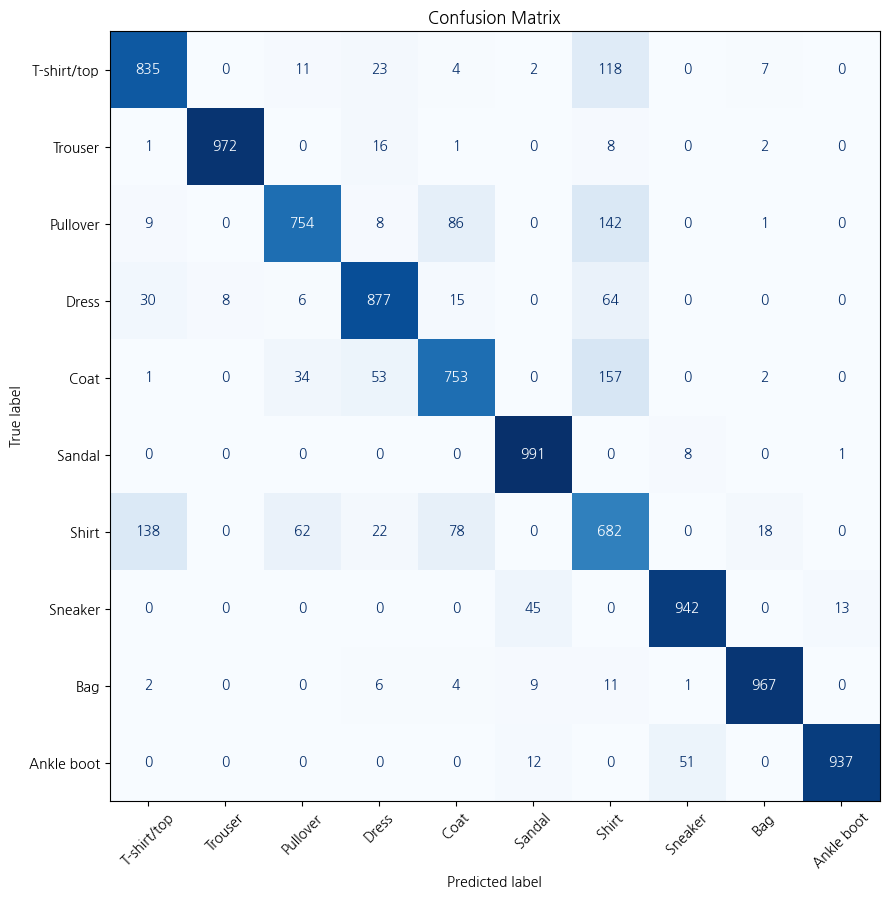

In [14]:
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

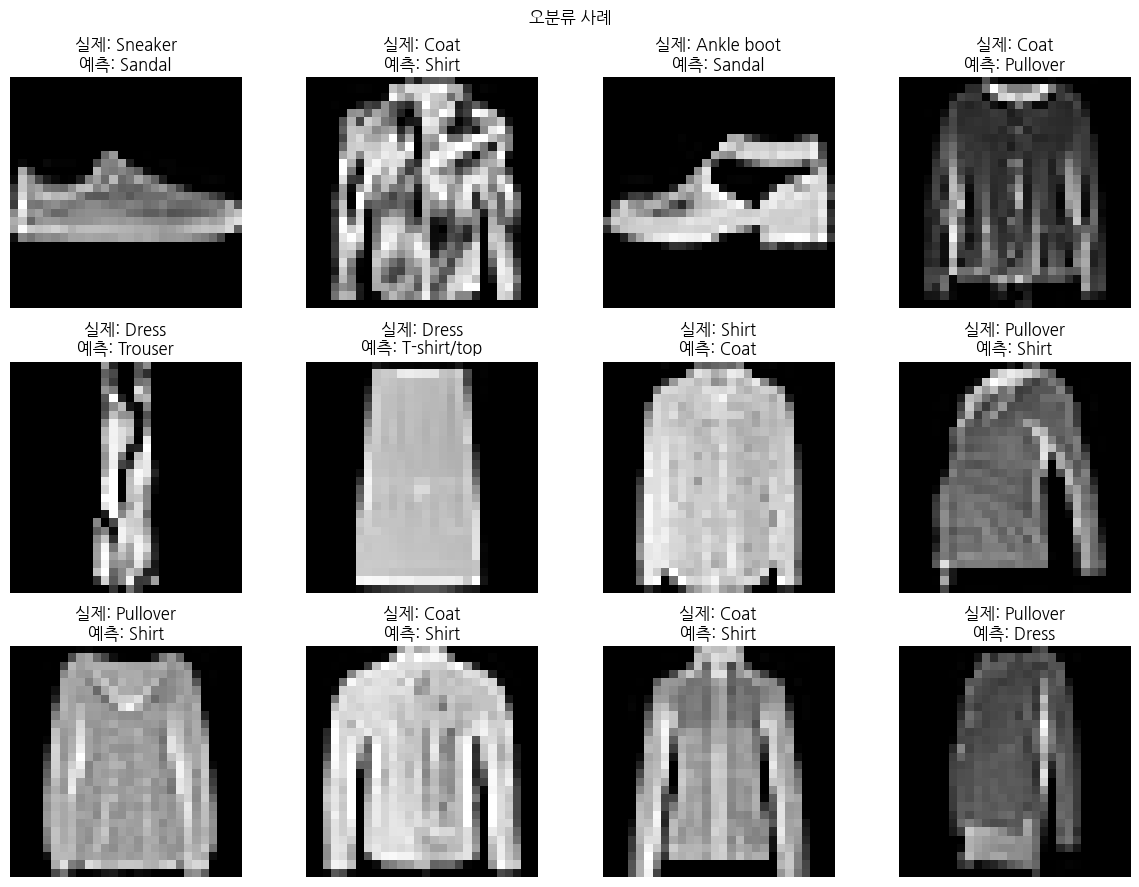

In [15]:
mis_idx = np.where(preds != y_test)[0][:12]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, idx in zip(axes.flatten(), mis_idx):
    ax.imshow(X_test[idx], cmap="gray")
    ax.set_title(f"실제: {class_names[y_test[idx]]}\n예측: {class_names[preds[idx]]}")
    ax.axis("off")

plt.suptitle("오분류 사례")
plt.tight_layout()
plt.show()

### 오분류 해석
대체로 자주 혼동되는 조합은 상의 계열과 일부 신발 계열에서 반복된다.  
예를 들어 Shirt, T-shirt/top, Pullover, Coat는 해상도가 낮을수록  
세부 구분 기준이 약해져 서로 섞이기 쉽다.

이는 단순히 모델 성능 부족으로만 보기 어렵다.  
원본 이미지 자체가 작고, 클래스 간 시각적 경계가 애초에 좁기 때문이다.  
따라서 이후 개선 방향은 모델을 무조건 더 복잡하게 만드는 것보다  
입력 품질과 데이터 적합성을 함께 고려하는 쪽이 더 타당하다.

## 6. 실제 사진 예측을 위한 전처리 파이프라인

학습 데이터와 실제 사진은 조건이 크게 다르다.  
실제 사진은 배경, 조명, 촬영 거리, 색상, 구도 등이 제각각이기 때문에  
훈련 데이터와 같은 방식으로 바로 해석되기 어렵다.

따라서 실제 사진을 입력할 때는  
학습 데이터와 가능한 한 비슷한 형태로 맞춰 주는 과정이 필요하다.  
이번 실험에서는 다음 순서로 전처리를 구성하였다.

1. 중앙 기준 정사각형 크롭  
2. 흑백 변환  
3. 대비 보정  
4. 필요 시 색 반전  
5. 28×28 축소  
6. 확대 확인을 통한 픽셀 상태 점검

마지막 확인 단계는 단순한 시각화가 아니라,  
모델이 받아들이는 입력이 Fashion MNIST와 어느 정도 유사한지 검토하는 절차에 가깝다.

In [16]:
def smart_crop_to_square(pil_img):
    w, h = pil_img.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    return pil_img.crop((left, top, left + side, top + side))

def prepare_fashion_like_image(img_path, show_steps=True):
    img = Image.open(img_path).convert("RGB")
    cropped = smart_crop_to_square(img)

    gray = ImageOps.grayscale(cropped)
    gray = ImageOps.autocontrast(gray)

    # 배경이 밝고 물체가 어두운 경우, Fashion MNIST 스타일에 맞추기 위해 반전
    arr_gray = np.array(gray)
    if arr_gray.mean() > 127:
        gray = ImageOps.invert(gray)

    # 명암을 조금 더 살려 윤곽을 분명하게
    gray = ImageEnhance.Contrast(gray).enhance(1.6)

    # 모델 입력용 28x28
    model_img = gray.resize((28, 28), Image.Resampling.BILINEAR)

    # 사람이 확인하기 위한 픽셀 확대본
    pixel_preview = model_img.resize((280, 280), Image.Resampling.NEAREST)

    model_arr = np.array(model_img, dtype=np.float32) / 255.0
    model_arr = model_arr.reshape(1, 28, 28, 1)

    if show_steps:
        fig, axes = plt.subplots(1, 4, figsize=(14, 4))
        axes[0].imshow(img)
        axes[0].set_title("원본")
        axes[1].imshow(cropped)
        axes[1].set_title("중앙 크롭")
        axes[2].imshow(gray, cmap="gray")
        axes[2].set_title("흑백/대비 보정")
        axes[3].imshow(pixel_preview, cmap="gray")
        axes[3].set_title("28×28 픽셀 확대본")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return model_arr, model_img, pixel_preview

## 7. 실제 이미지 예측 실험

이 단계에서는 실제 이미지를 전처리한 뒤 모델에 입력하여  
훈련 데이터 밖의 사례에 대해서도 예측이 어느 정도 성립하는지 확인한다.

실제 사진 예측 결과는 모델 구조만으로 설명되기보다  
전처리 품질에 크게 좌우된다.  
따라서 결과값 자체와 함께, 입력 이미지가 얼마나 단순화되었는지도 함께 보는 것이 중요하다.

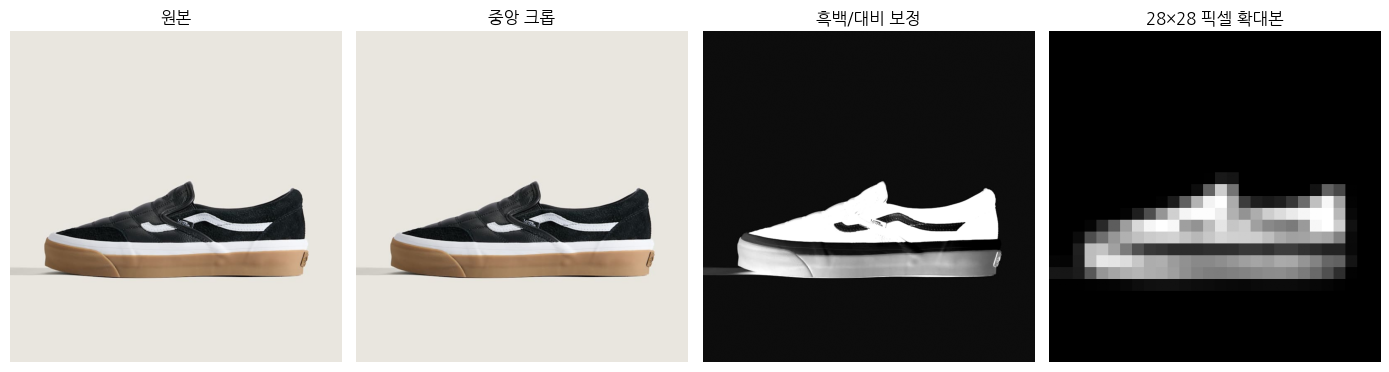

[파일] VN000Z62BA2-ALT20.jpg
예측 클래스: Sneaker
신뢰도: 0.7088


,class,probability
7,Sneaker,0.708806
5,Sandal,0.206927
8,Bag,0.028441
9,Ankle boot,0.020708
6,Shirt,0.015663


------------------------------------------------------------


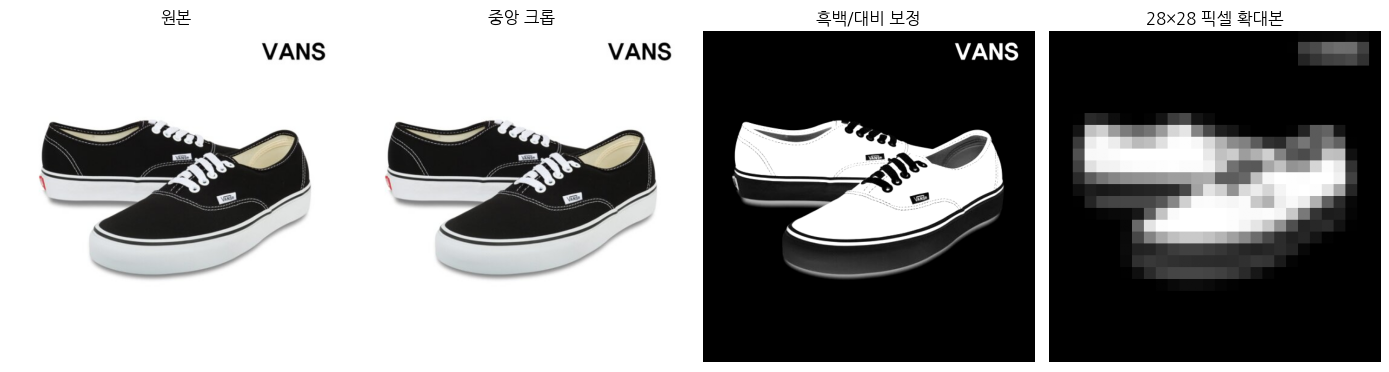

[파일] 550.jpg
예측 클래스: Bag
신뢰도: 0.8910


,class,probability
8,Bag,0.890969
0,T-shirt/top,0.096511
6,Shirt,0.005448
5,Sandal,0.003382
7,Sneaker,0.002394


------------------------------------------------------------


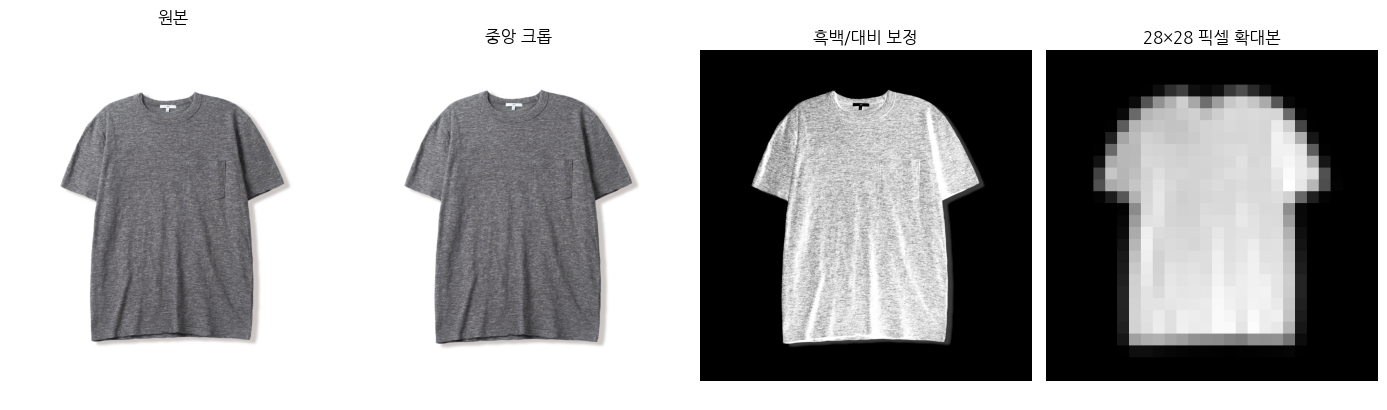

[파일] 9a2261340cf0dd58ab0db38bc86b35a9.png
예측 클래스: T-shirt/top
신뢰도: 0.4928


,class,probability
0,T-shirt/top,0.492761
6,Shirt,0.312373
3,Dress,0.074681
8,Bag,0.060453
4,Coat,0.044941


------------------------------------------------------------


In [17]:
test_images = [
    "VN000Z62BA2-ALT20.jpg",
    "550.jpg",
    "9a2261340cf0dd58ab0db38bc86b35a9.png"
]

available_images = [p for p in test_images if os.path.exists(p)]

if not available_images:
    print("현재 작업 폴더에 테스트 이미지가 없습니다. test_images 경로를 바꿔서 사용하세요.")
else:
    for img_path in available_images:
        model_arr, model_img, pixel_preview = prepare_fashion_like_image(img_path, show_steps=True)

        pred = final_model.predict(model_arr, verbose=0)[0]
        pred_label = int(np.argmax(pred))
        pred_conf = float(np.max(pred))

        print(f"[파일] {img_path}")
        print(f"예측 클래스: {class_names[pred_label]}")
        print(f"신뢰도: {pred_conf:.4f}")

        prob_df = pd.DataFrame({
            "class": class_names,
            "probability": pred
        }).sort_values("probability", ascending=False)

        display(prob_df.head(5))
        print("-" * 60)

실제 사진 예측에서는 최종 클래스만 확인하는 것보다 전처리된 28x28 이미지의 형태를 함께 보는 것이 중요하다.
물체 윤곽이 유지되고 배경이 충분히 단순화되어 있다면 예측 결과를 비교적 신뢰할 수 있지만,
윤곽이 흐리거나 배경 흔적이 많이 남아 있으면 모델이 학습 데이터와 다른 패턴으로 받아들일 가능성이 크다.

## 8. 종합 정리

이번 실험에서는 DNN, 기본 CNN, 개선 CNN을 순차적으로 비교하면서  
모델 구조의 차이와 학습 안정화의 효과를 함께 살펴보았다.

전체 흐름을 정리하면 다음과 같다.

### 1) 입력 구조를 보존하는 방식이 더 적합했다
Fashion MNIST는 작은 흑백 이미지이지만,  
의류의 형태와 위치 관계가 중요한 데이터이기 때문에  
평탄화 기반 DNN보다 CNN이 더 설득력 있는 결과를 보였다.

### 2) 성능 향상은 구조의 복잡성보다 학습 안정화에서 나타났다
개선 CNN은 Batch Normalization, Dropout, Callback, 보수적 증강을 통해  
검증 성능의 흔들림을 줄이고 비교적 안정적인 결과를 확보하는 방향으로 작동했다.

### 3) 실제 사진 적용에서는 전처리의 역할이 컸다
실제 사진은 학습 데이터와 분포 차이가 크기 때문에,  
이미지를 Fashion MNIST와 비슷한 형태로 단순화하는 과정이  
예측 가능성을 높이는 핵심 조건으로 작용했다.

### 4) 남는 과제
향후에는 배경 제거, 실제 의류 사진 추가, 클래스별 오분류 보완 등  
데이터 측면의 개선을 함께 진행할 경우 더 실질적인 성능 향상이 가능할 것으로 보인다.